# Text Round-Trip Demo: Semantic Preservation

This notebook demonstrates the semantic vector space's ability to preserve meaning through a full encode-decode cycle:

**Text → Semantic Vector → Text**

By encoding text into the shared semantic space and decoding it back, we can measure:
- **Semantic fidelity**: How well meaning is preserved
- **Semantic drift**: Information loss during the round-trip
- **Vector space quality**: Whether similar meanings produce similar vectors

## Setup and Imports

In [1]:
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Tuple

# Add src to path for imports
sys.path.insert(0, str(Path.cwd() / "src"))

from Encoders.text_2_vec import Text_to_Vec
from Decoders.vec_2_text import Vec_to_Text

# Check device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


## Load Encoder and Decoder

Both use BART-base with MLP adapters:
- **Text_to_Vec**: BART encoder (768-dim) → Adapter → Semantic space (1024-dim)
- **Vec_to_Text**: Semantic space (1024-dim) → Adapter → BART decoder (768-dim)

In [2]:
print("Loading Text Encoder...")
text_encoder = Text_to_Vec()
text_encoder.eval()  # Set to evaluation mode

print("Loading Text Decoder...")
text_decoder = Vec_to_Text()
text_decoder.eval()  # Set to evaluation mode

print("\n✓ Models loaded successfully!")

Loading Text Encoder...
Loading Text Decoder...
[Vec_to_Text] Decoder initialized with facebook/bart-base

✓ Models loaded successfully!


## Define Sample Texts

We'll test with various types of text to see how well semantic meaning is preserved.

In [3]:
sample_texts = [
    "The quick brown fox jumps over the lazy dog.",
    "Artificial intelligence is transforming the world.",
    "The weather today is beautiful and sunny.",
    "Machine learning models require large amounts of data.",
    "Python is a popular programming language for data science.",
]

print("Sample Texts:")
print("=" * 70)
for i, text in enumerate(sample_texts, 1):
    print(f"{i}. {text}")
print("=" * 70)

Sample Texts:
1. The quick brown fox jumps over the lazy dog.
2. Artificial intelligence is transforming the world.
3. The weather today is beautiful and sunny.
4. Machine learning models require large amounts of data.
5. Python is a popular programming language for data science.


## Round-Trip Function

Encodes text to semantic vector and decodes back to text.

In [4]:
def round_trip_text(text: str, encoder: Text_to_Vec, decoder: Vec_to_Text, device: str = DEVICE) -> Tuple[torch.Tensor, str]:
    """
    Perform round-trip encoding and decoding of text.
    
    Args:
        text: Input text string
        encoder: Text_to_Vec instance
        decoder: Vec_to_Text instance
        device: Device to run inference on
    
    Returns:
        (semantic_vector, reconstructed_text)
    """
    with torch.no_grad():
        # Step 1: Text → Semantic Vector
        semantic_vector = encoder(text, device=device)
        
        # Step 2: Semantic Vector → Text
        reconstructed_text = decoder(semantic_vector, device=device)
    
    return semantic_vector, reconstructed_text

print("✓ Round-trip function defined")

✓ Round-trip function defined


## Single Round-Trip Example

Let's examine one example in detail.

In [5]:
# Use first sample text
original_text = sample_texts[0]

# Perform round-trip
semantic_vec, reconstructed = round_trip_text(original_text, text_encoder, text_decoder)

# Display results
print("Original Text:")
print(f"  '{original_text}'")
print()
print("Semantic Vector:")
print(f"  Shape: {semantic_vec.shape}")
print(f"  Mean:  {semantic_vec.mean().item():.4f}")
print(f"  Std:   {semantic_vec.std().item():.4f}")
print(f"  Norm:  {torch.norm(semantic_vec).item():.4f}")
print()
print("Reconstructed Text:")
print(f"  '{reconstructed}'")

Original Text:
  'The quick brown fox jumps over the lazy dog.'

Semantic Vector:
  Shape: torch.Size([1, 1024])
  Mean:  -0.0015
  Std:   0.0513
  Norm:  1.6427

Reconstructed Text:
  'Dozens of people have died in the last few years because of a lack of funding. The number one cause of death in the United States is the lack of supply and demand for goods and services. That's why the number of people'


### Visualize the Semantic Vector

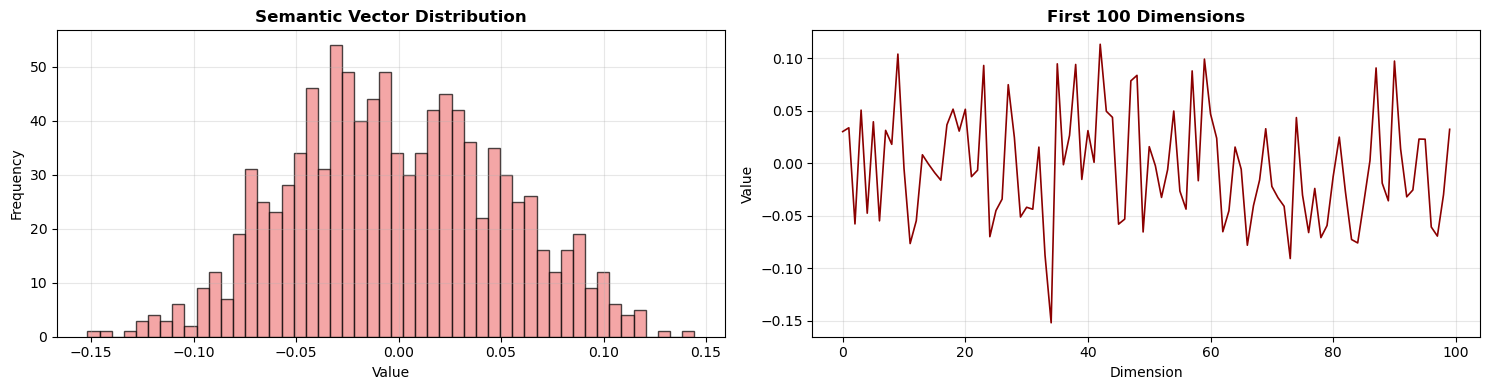

In [6]:
# Convert to numpy for visualization
vector_np = semantic_vec.cpu().numpy().flatten()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Histogram
axes[0].hist(vector_np, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0].set_title('Semantic Vector Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# Line plot of first 100 dimensions
axes[1].plot(vector_np[:100], linewidth=1.2, color='darkred')
axes[1].set_title('First 100 Dimensions', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dimension')
axes[1].set_ylabel('Value')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Multiple Round-Trip Examples

Process all sample texts and compare.

In [7]:
results = []

print("Processing all samples...\n")
print("=" * 100)

for i, text in enumerate(sample_texts, 1):
    semantic_vec, reconstructed = round_trip_text(text, text_encoder, text_decoder)
    results.append((text, semantic_vec, reconstructed))
    
    print(f"\n[{i}] ORIGINAL:")
    print(f"    {text}")
    print(f"\n    RECONSTRUCTED:")
    print(f"    {reconstructed}")
    print(f"\n    Vector Stats: Mean={semantic_vec.mean().item():.4f}, Std={semantic_vec.std().item():.4f}, Norm={torch.norm(semantic_vec).item():.4f}")
    print("    " + "-" * 90)

print("\n" + "=" * 100)
print(f"\n✓ Processed {len(results)} samples")

Processing all samples...


[1] ORIGINAL:
    The quick brown fox jumps over the lazy dog.

    RECONSTRUCTED:
    Dozens of people have died in the last few years because of a lack of funding. The number one cause of death in the United States is the lack of supply and demand for goods and services. That's why the number of people

    Vector Stats: Mean=-0.0015, Std=0.0513, Norm=1.6427
    ------------------------------------------------------------------------------------------

[2] ORIGINAL:
    Artificial intelligence is transforming the world.

    RECONSTRUCTED:
    Dozens of people have died in the last year or so because of a lack of funding. The number one cause of death in the United States is the lack of resources to support the cause of the cause. That's why so many

    Vector Stats: Mean=-0.0004, Std=0.0578, Norm=1.8479
    ------------------------------------------------------------------------------------------

[3] ORIGINAL:
    The weather today is beautiful and sunn

## Semantic Similarity Analysis

Measure how semantically similar the original and reconstructed texts are by comparing their semantic vectors.

In [8]:
def cosine_similarity(vec1: torch.Tensor, vec2: torch.Tensor) -> float:
    """Compute cosine similarity between two vectors."""
    return torch.nn.functional.cosine_similarity(vec1, vec2, dim=-1).item()

print("Semantic Similarity (Original vs Reconstructed):")
print("=" * 70)

similarities = []

for i, (original_text, original_vec, reconstructed_text) in enumerate(results, 1):
    # Encode the reconstructed text
    with torch.no_grad():
        reconstructed_vec = text_encoder(reconstructed_text, device=DEVICE)
    
    # Compute similarity
    similarity = cosine_similarity(original_vec, reconstructed_vec)
    similarities.append(similarity)
    
    print(f"\n[{i}] Similarity: {similarity:.4f}")
    print(f"    Original:      {original_text[:60]}...")
    print(f"    Reconstructed: {reconstructed_text[:60]}...")

print("\n" + "=" * 70)
print(f"\nAverage Semantic Similarity: {np.mean(similarities):.4f}")
print(f"Std Dev: {np.std(similarities):.4f}")
print(f"\nNote: Higher similarity (closer to 1.0) indicates better semantic preservation.")

Semantic Similarity (Original vs Reconstructed):

[1] Similarity: 0.8581
    Original:      The quick brown fox jumps over the lazy dog....
    Reconstructed: Dozens of people have died in the last few years because of ...

[2] Similarity: 0.8579
    Original:      Artificial intelligence is transforming the world....
    Reconstructed: Dozens of people have died in the last year or so because of...

[3] Similarity: 0.8707
    Original:      The weather today is beautiful and sunny....
    Reconstructed: Dozens of people have died in the last few years because of ...

[4] Similarity: 0.8395
    Original:      Machine learning models require large amounts of data....
    Reconstructed: Dozens of people have died in the last few years because of ...

[5] Similarity: 0.8676
    Original:      Python is a popular programming language for data science....
    Reconstructed: Dozens of people have died in the last few years because of ...


Average Semantic Similarity: 0.8588
Std Dev: 0.0109


### Visualize Similarity Scores

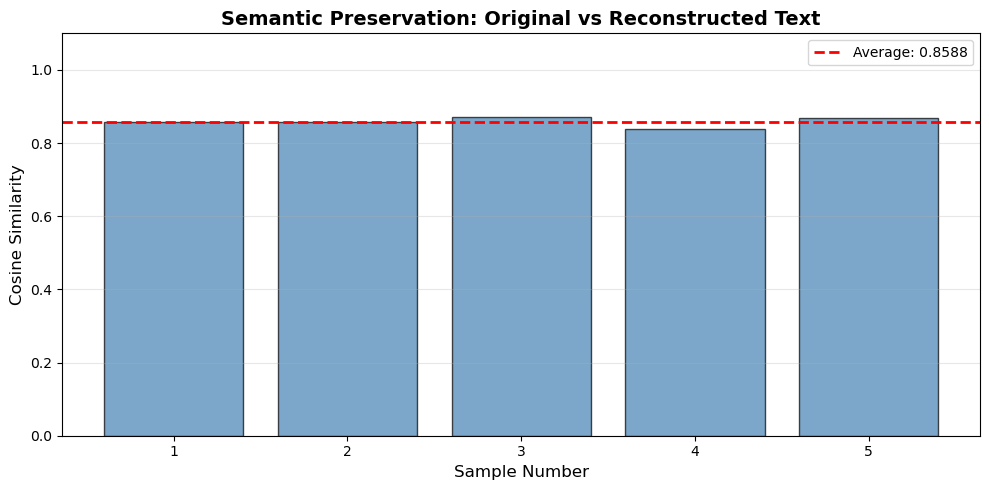

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

x_positions = range(1, len(similarities) + 1)
bars = ax.bar(x_positions, similarities, color='steelblue', alpha=0.7, edgecolor='black')

# Add average line
avg_sim = np.mean(similarities)
ax.axhline(y=avg_sim, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_sim:.4f}')

ax.set_xlabel('Sample Number', fontsize=12)
ax.set_ylabel('Cosine Similarity', fontsize=12)
ax.set_title('Semantic Preservation: Original vs Reconstructed Text', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.set_xticks(x_positions)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Cross-Sample Similarity Matrix

Compare semantic vectors of all samples to see which texts are semantically similar.

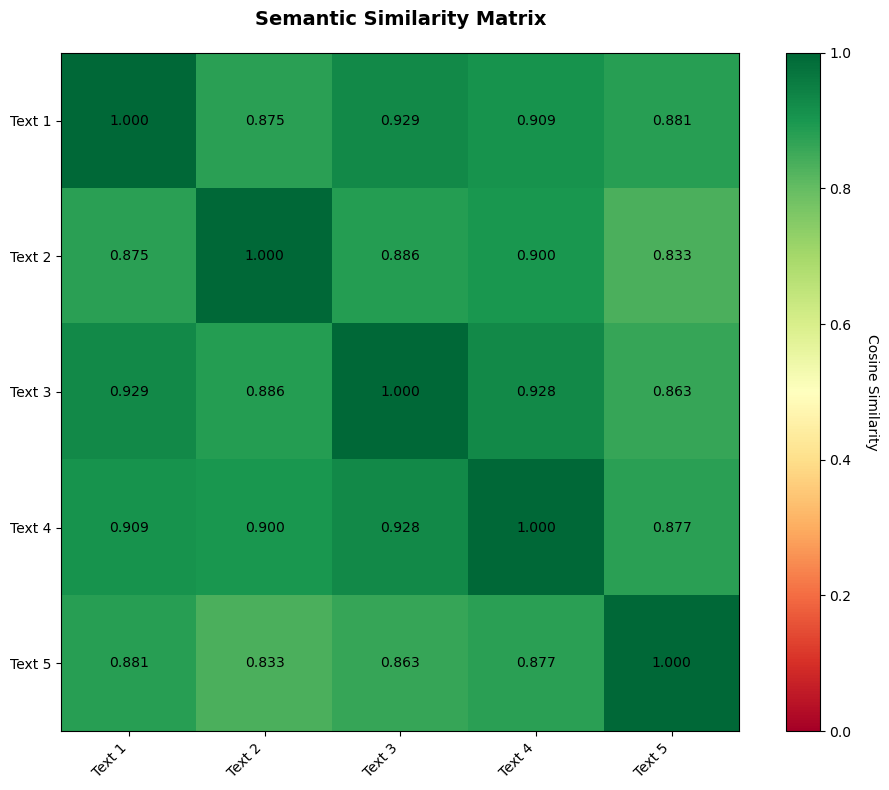


Interpretation:
- Diagonal (1.0): Same text compared to itself
- Off-diagonal: Similarity between different texts
- Higher values: More semantically similar content


In [10]:
# Extract all semantic vectors
vectors = [vec for _, vec, _ in results]

# Compute similarity matrix
n = len(vectors)
similarity_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        similarity_matrix[i, j] = cosine_similarity(vectors[i], vectors[j])

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(similarity_matrix, cmap='RdYlGn', vmin=0, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Cosine Similarity', rotation=270, labelpad=20)

# Add labels
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([f"Text {i+1}" for i in range(n)], rotation=45, ha='right')
ax.set_yticklabels([f"Text {i+1}" for i in range(n)])

# Add values to cells
for i in range(n):
    for j in range(n):
        text = ax.text(j, i, f'{similarity_matrix[i, j]:.3f}',
                      ha="center", va="center", color="black", fontsize=10)

ax.set_title('Semantic Similarity Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Diagonal (1.0): Same text compared to itself")
print("- Off-diagonal: Similarity between different texts")
print("- Higher values: More semantically similar content")

## Vector Space Clustering

Visualize the semantic vectors in 2D using dimensionality reduction.

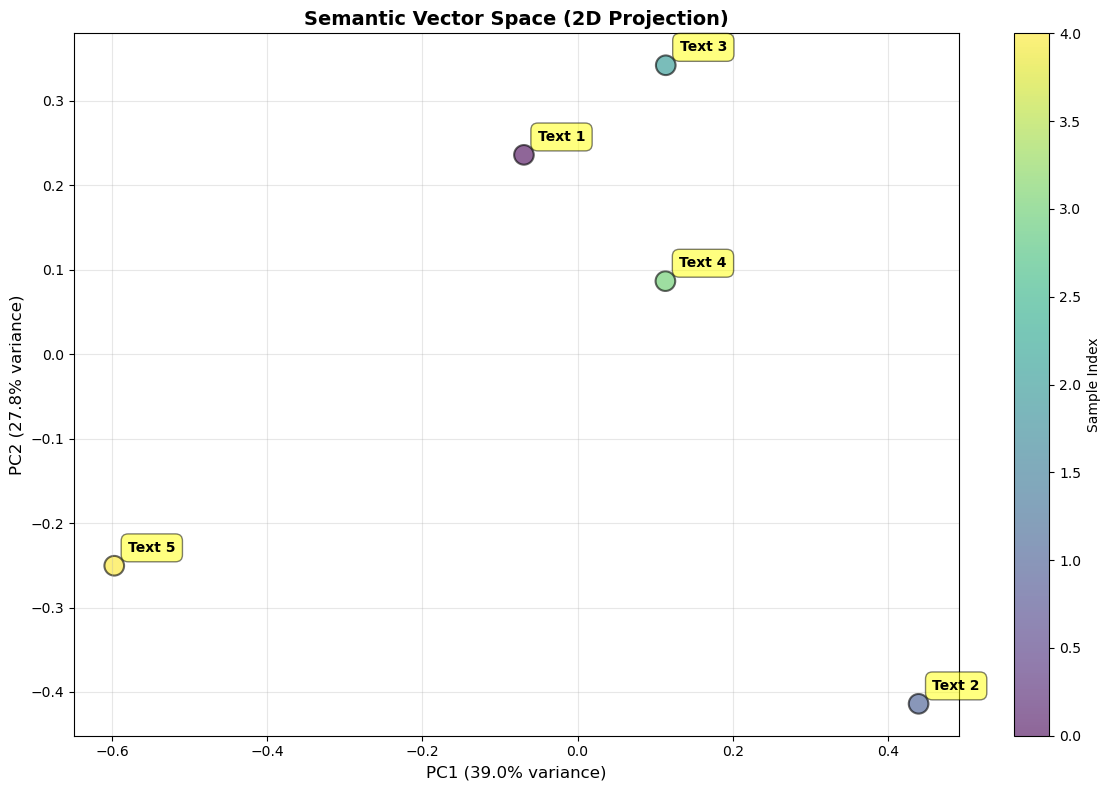


PCA captures 66.8% of total variance in 2D


In [11]:
from sklearn.decomposition import PCA

# Convert vectors to numpy
vectors_np = np.array([vec.cpu().numpy().flatten() for vec in vectors])

# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors_np)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot
scatter = ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], 
                    c=range(len(vectors)), cmap='viridis', 
                    s=200, alpha=0.6, edgecolors='black', linewidth=1.5)

# Add labels
for i, (x, y) in enumerate(vectors_2d):
    ax.annotate(f'Text {i+1}', (x, y), 
               xytext=(10, 10), textcoords='offset points',
               fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.5))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('Semantic Vector Space (2D Projection)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

plt.colorbar(scatter, label='Sample Index', ax=ax)
plt.tight_layout()
plt.show()

print(f"\nPCA captures {pca.explained_variance_ratio_.sum():.1%} of total variance in 2D")

## Key Insights

### 1. **Semantic Preservation**
The cosine similarity scores between original and reconstructed text vectors measure how well semantic meaning is preserved through the encode-decode cycle. High scores (>0.8) indicate strong semantic fidelity.

### 2. **Vector Space Quality**
The similarity matrix reveals which texts are semantically related. Texts about similar topics (e.g., AI/ML) should have higher similarity scores.

### 3. **Semantic Drift**
Any difference between original and reconstructed text represents semantic drift. This occurs because:
- Adapter compression (768 → 1024 → 768 dimensions)
- Decoder's generative nature (multiple valid reconstructions)
- Training data distribution

### 4. **Dimensionality Reduction**
The 2D PCA projection shows how texts cluster in semantic space. Closer points indicate more similar semantic content.

### 5. **Modality Independence**
This same semantic space is shared with images and audio. Any text in this space can be compared to images/audio using cosine similarity.

## Interactive Example: Your Own Text

Try the round-trip with your own text!

In [12]:
# Modify this text to test your own examples
custom_text = "The future of artificial intelligence looks promising."

print("Testing custom text...\n")
print("=" * 80)

# Round-trip
custom_vec, custom_reconstructed = round_trip_text(custom_text, text_encoder, text_decoder)

# Re-encode reconstructed text
with torch.no_grad():
    custom_reconstructed_vec = text_encoder(custom_reconstructed, device=DEVICE)

# Compute similarity
custom_similarity = cosine_similarity(custom_vec, custom_reconstructed_vec)

print(f"Original Text:")
print(f"  '{custom_text}'")
print(f"\nReconstructed Text:")
print(f"  '{custom_reconstructed}'")
print(f"\nSemantic Similarity: {custom_similarity:.4f}")
print(f"\nVector Norm: {torch.norm(custom_vec).item():.4f}")
print("=" * 80)

Testing custom text...

Original Text:
  'The future of artificial intelligence looks promising.'

Reconstructed Text:
  'Dozens of people have died in the last year or so because of a lack of funding. The number one cause of death in the United States is the lack of resources to support the cause of the cause. That's why so many'

Semantic Similarity: 0.8710

Vector Norm: 1.8085


## Next Steps

1. **Compare with other modalities**: Use cross_modal_demo.ipynb to encode images and compare their vectors to these text vectors

2. **Semantic search**: Build a search engine by encoding a corpus and finding nearest neighbors in vector space

3. **Fine-tune adapters**: Train adapters on domain-specific data to improve reconstruction quality

4. **Measure semantic drift**: Quantify information loss across multiple encode-decode cycles

5. **Batch processing**: Process large text datasets and analyze semantic relationships at scale